<a href="https://colab.research.google.com/github/MarioRojasV/CNN_Models_Comparison_Bird_Classification/blob/main/src/mobilenetv2_model/MobileNetV2_Birds_COMPDES_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [103]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [104]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [105]:
os.listdir('/content/drive/MyDrive')

['Universidad', 'Colab Notebooks']

In [106]:
BASE_PATH = "/content/drive/MyDrive/Universidad/COMPDES2026_Aves_CR/Dataset"

train_path = BASE_PATH + "/Training_set"
validation_path = BASE_PATH + "/Validation_set"
test_path = BASE_PATH + "/Test_set"

In [107]:
os.listdir(BASE_PATH)

['Testing_set', 'Training_set', 'Validation_set', 'Whole_dataset']

In [108]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

BATCH_SIZE = 32

In [109]:
train_ds = image_dataset_from_directory(
    train_path,
    image_size=(224,224),
    batch_size=BATCH_SIZE,
    pad_to_aspect_ratio=True
)

val_ds = image_dataset_from_directory(
    validation_path,
    image_size=(224,224),
    batch_size=BATCH_SIZE,
    pad_to_aspect_ratio=True
)

Found 340 files belonging to 2 classes.
Found 80 files belonging to 2 classes.


In [110]:
class_names = train_ds.class_names

print(class_names)

['Quiscalus_mexicanus_female', 'Turdus_grayi']


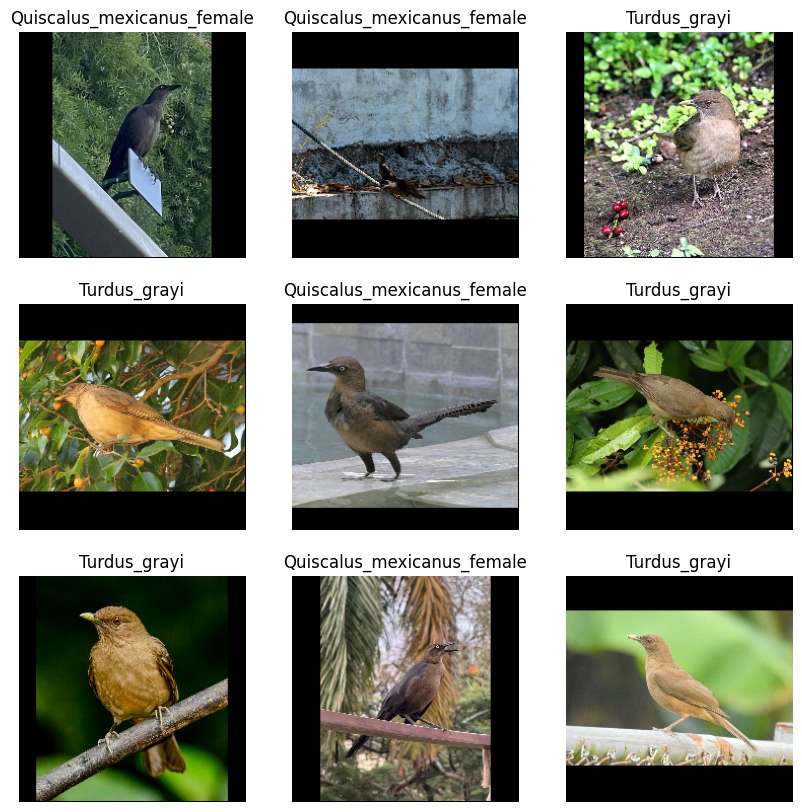

In [111]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [112]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(
        0.05,
        fill_mode="reflect"
    ),

    tf.keras.layers.RandomZoom(
        0.05,
        fill_mode="reflect"
    )
])

In [113]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

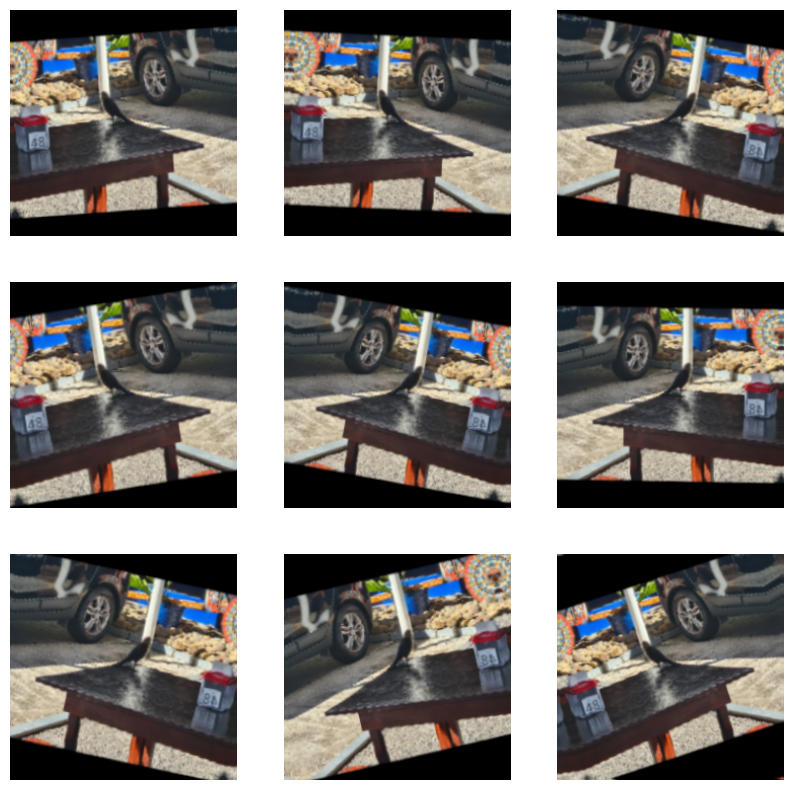

In [114]:
for images, labels in train_ds.take(1):
    original = images[0]

plt.figure(figsize=(10,10))

for i in range(9):
    augmented = data_augmentation(
        tf.expand_dims(original,0),
        training=True
    )[0]

    ax = plt.subplot(3,3,i+1)
    plt.imshow(augmented.numpy().astype("uint8"))
    plt.axis("off")

In [115]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [116]:
train_ds = train_ds.map(
    lambda x, y: (preprocess_input(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (preprocess_input(x), y)
)

In [117]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [118]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

In [119]:
base_model.trainable = False

In [121]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

dropout_layer = tf.keras.layers.Dropout(0.5)

prediction_layer = tf.keras.layers.Dense(
    2,
    activation="softmax"
)

In [122]:
inputs = tf.keras.Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = global_average_layer(x)

x = dropout_layer(x)

outputs = prediction_layer(x)


model = tf.keras.Model(
    inputs,
    outputs
)

In [123]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [124]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [125]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 72s 5s/step - accuracy: 0.5500 - loss: 0.8701 - val_accuracy: 0.7375 - val_loss: 0.4976
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7088 - loss: 0.6166 - val_accuracy: 0.7750 - val_loss: 0.3933
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7353 - loss: 0.5507 - val_accuracy: 0.8875 - val_loss: 0.3196
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7882 - loss: 0.4932 - val_accuracy: 0.8500 - val_loss: 0.3082
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8412 - loss: 0.3542 - val_accuracy: 0.9125 - val_loss: 0.2741
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8382 - loss: 0.3677 - val_accuracy: 0.9000 - val_loss: 0.2711
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8559 - loss: 0.3453 - val_accuracy: 0.9250 - val_loss: 0.2457
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8588 - loss: 0.3277 - val_accuracy: 0.9000 - val_loss:

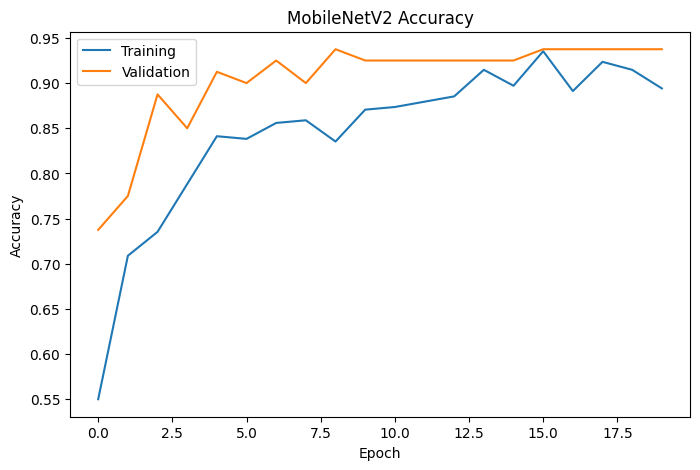

In [126]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Training',
    'Validation'
])

plt.title('MobileNetV2 Accuracy')
plt.show()

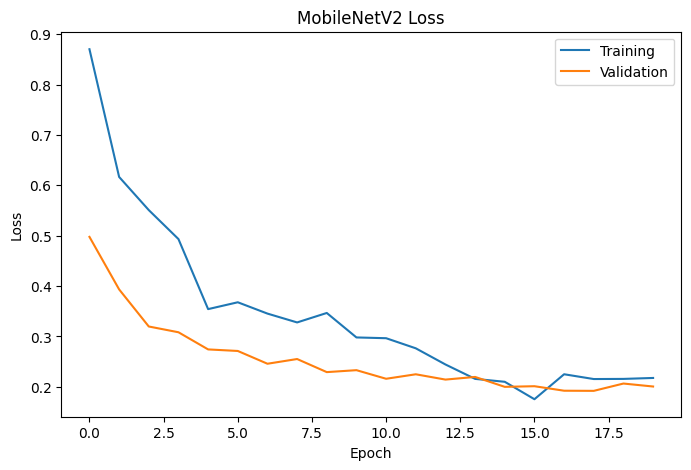

In [127]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend([
    'Training',
    'Validation'
])

plt.title('MobileNetV2 Loss')
plt.show()

In [128]:
model.save(
    "/content/drive/MyDrive/Universidad/COMPDES2026_Aves_CR/Resultados_MobileNetV2/MobileNetV2_baseline.keras"
)

In [129]:
import pickle

with open(
    "/content/drive/MyDrive/Universidad/COMPDES2026_Aves_CR/Resultados_MobileNetV2/MobileNetV2_history.pkl",
    "wb"
) as file:
    pickle.dump(history.history, file)

In [130]:
results = {
    "modelo": "MobileNetV2 Transfer Learning",
    "imagenes": "Turdus grayi vs Quiscalus mexicanus female",
    "input_size": "224x224",
    "epochs": 20,
    "train_accuracy_final": float(history.history["accuracy"][-1]),
    "val_accuracy_final": float(history.history["val_accuracy"][-1]),
    "train_loss_final": float(history.history["loss"][-1]),
    "val_loss_final": float(history.history["val_loss"][-1])
}

print(results)

{'modelo': 'MobileNetV2 Transfer Learning', 'imagenes': 'Turdus grayi vs Quiscalus mexicanus female', 'input_size': '224x224', 'epochs': 20, 'train_accuracy_final': 0.8941176533699036, 'val_accuracy_final': 0.9375, 'train_loss_final': 0.21748468279838562, 'val_loss_final': 0.20050308108329773}
